# Customer Segmentation Clustering Model


## Introduction

**What is the goal of this lab?**

In this lab you will practice building, validating, and evaluating clustering models for a customer segmentation problem.

**Context**

Clustering helps find the groupings of data points when you do not have explicit labels to do classification. A cannonical example of clustering applicable to almost any business is _customer segmentation_. Customer segmentation is the strategic process of dividing a customer base into distinct groups with similar characteristics, such as demographics, purchasing behaviors, or preferences, to tailor marketing efforts, enhance customer service, and optimize product offerings.

### Data



This lab uses the _Wholesale customers_ data set about grocery food category sales in Portugal 🇵🇹.

In [ ]:
# Install package to download data sets from UCI ML Repo
!pip3 install -U ucimlrepo --quiet
from ucimlrepo import fetch_ucirepo

In [ ]:
# Get the data set
customers = fetch_ucirepo(name="Wholesale customers")

In [ ]:
# Get raw data in a pandas.DataFrame format
customers_df = customers.data.original

In [ ]:
# Citation
print("Citation:\n", customers.metadata.additional_info.citation)

Citation:
 None


> *Cardoso, Margarida. (2014). Wholesale customers.*     
> *UCI Machine Learning Repository. https://doi.org/10.24432/C5030X.*

In [ ]:
# More information
print("Check out this data set on the UCI ML Repository for more information:")
print(customers.metadata.repository_url)

Check out this data set on the UCI ML Repository for more information:
https://archive.ics.uci.edu/dataset/292/wholesale+customers


## Problem Statement

**What are we trying to cluster into groups and what are some potential characteristics of the groups?**




_Chracteristics could include demographics, purchasing behaviors, or preferences depending on the dataset._

**How could this model be used once it is validated? What is the main benefit of building this model?**

_Once it is validated is can be used to identify hidden patterns, that can help in making data driven decisions._


**How often would the resulting model be used? And how often do you think it would it need to be retrained on new data and why?**

_I think it would be used on weekly and/or montly bases. Retraining should happen I think, every 6 months, so that clusters stay relevant and keep showing the latest trends._

**How "good" or accurate do you think this model needs to be for it to be useful? What metrics are being used to define a "good" vs. "bad" model?**


_I think i needs to be quite accurate like more than 80%, but I also think it does not need to be perfect. To check, we can use scores like Silhouette and/or Calinski score._


## Exploratory Data Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Inspection

Print out the following details about the data:
- The first 5 rows of the data set
- Number of rows and columns
- Data type of each column
- Number of null values (or not-null values) in each column
- General statistics of each numeric column (min, max, mean, standard deviation)

---

**Hints**

- [`pandas.DataFrame.head()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html)
- [`pandas.DataFrame.info()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html)
- [`pandas.DataFrame.describe()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html)

In [ ]:
customers_df.head()
print(customers_df.shape)
print(customers_df.info())
print(customers_df.isnull().sum())
customers_df.describe()


(440, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


### Data Cleaning

Clustering algorithms work much better if all the features are on the same scale. For the rest of the lab we are only going to work with the numeric columns: `['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']`.


We are going to experiment with clustering algorithms on _2 different data scaling techniques_ to see which works better.

**Z-score Standardization**

1. First, scale each column using Z-score standardization by substrating the column mean and dividing by the standard deviation.
2. Second, filter out any outlier rows where the Z-score in any column is greater than 5 or less than -5 (meaning the data point is more than 5 standard deviations away from the mean). Print out how many rows get filtered out using this outlier detection method.

**Log Transformation**

1. Apply a natural log (log base _e_) transform to each value in the data set.
2. Are there any outliers that are more than 5 standard deviations away from the mean after this log transform? If so, print out how many remove them from the the data set.


---

**Hints**

_Z-score Standardization_
- [`sklearn.preprocessing.StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) _or_ [`pandas.DataFrame.mean()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.mean.html) & [`pandas.DataFrame.std()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.std.html#pandas.DataFrame.std)

_Log transform_
- [`numpy.log()`](https://numpy.org/doc/stable/reference/generated/numpy.log.html)

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

cols = ['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']
data = customers_df[cols]

# Z-score
scaler = StandardScaler()
z = scaler.fit_transform(data)
z = pd.DataFrame(z, columns=cols)
print("Z-score outliers:", (abs(z) > 5).any(axis=1).sum())
z = z[(abs(z) <= 5).all(axis=1)]

# Log
log = np.log(data + 1)
log = scaler.fit_transform(log)
log = pd.DataFrame(log, columns=cols)
print("Log outliers:", (abs(log) > 5).any(axis=1).sum())
log = log[(abs(log) <= 5).all(axis=1)]


Z-score outliers: 11
Log outliers: 3


### Data Visualizations and Statistics

#### Data Visualization

For each of the 6 variables create a histogram or density plot to show the distribution of that variable. Then create scatter plots for every pair of variables. Do this for both the Z-score standardized data set and the log transformed data set.

---
**Hints**

- [`seaborn.pairplot()`](https://seaborn.pydata.org/generated/seaborn.pairplot.html) _or_ [`pandas.plotting.scatter_matrix()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.plotting.scatter_matrix.html#pandas.plotting.scatter_matrix)

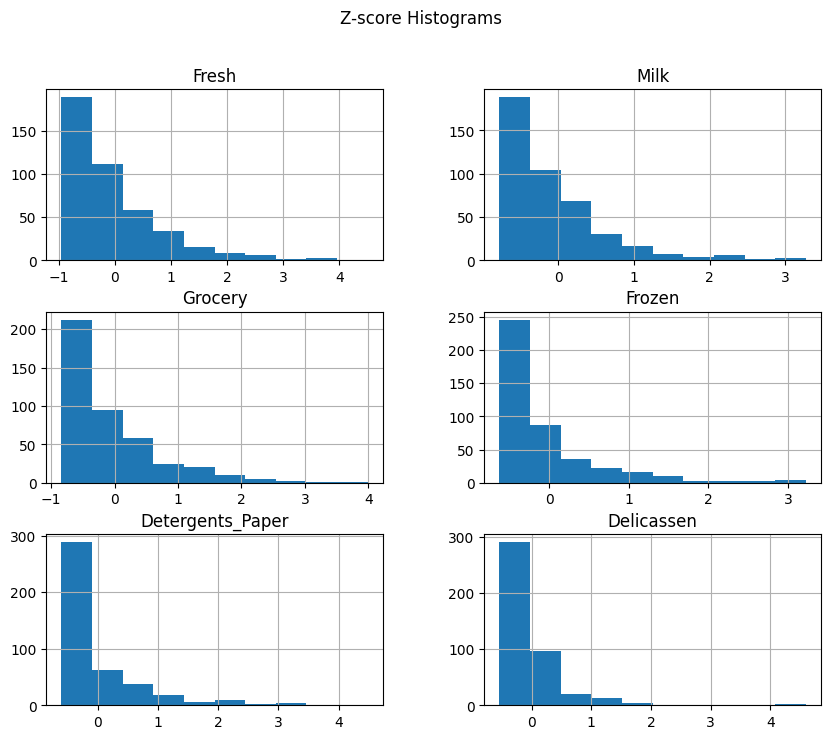

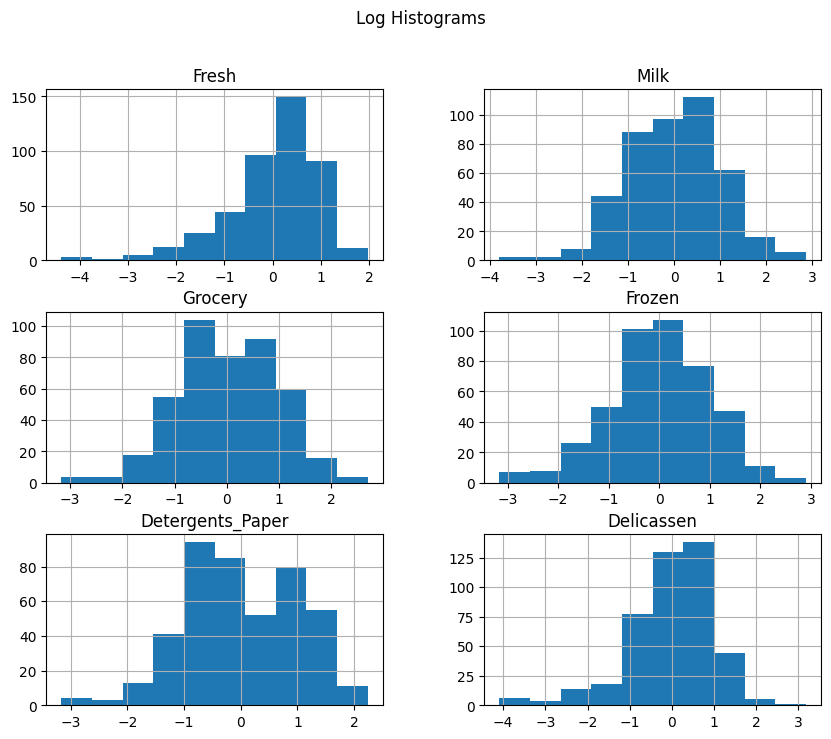

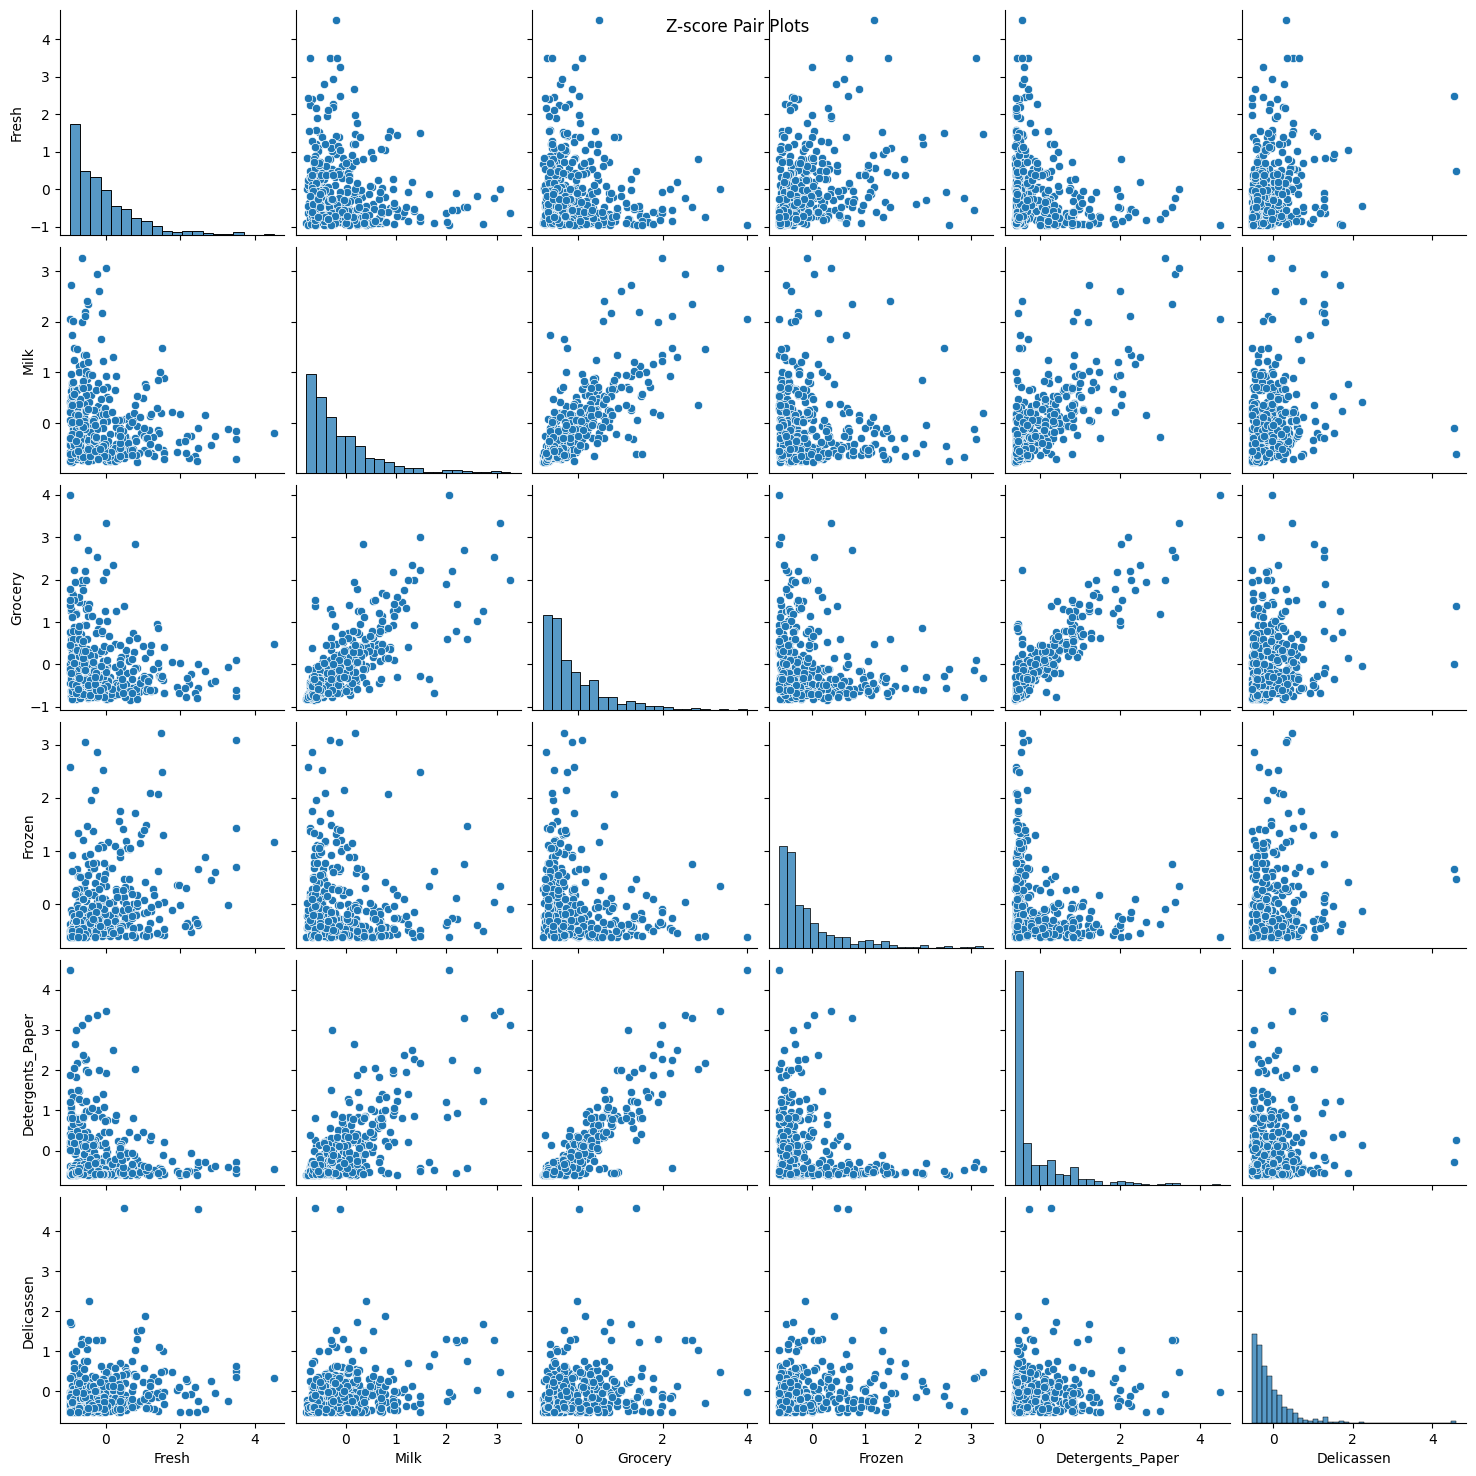

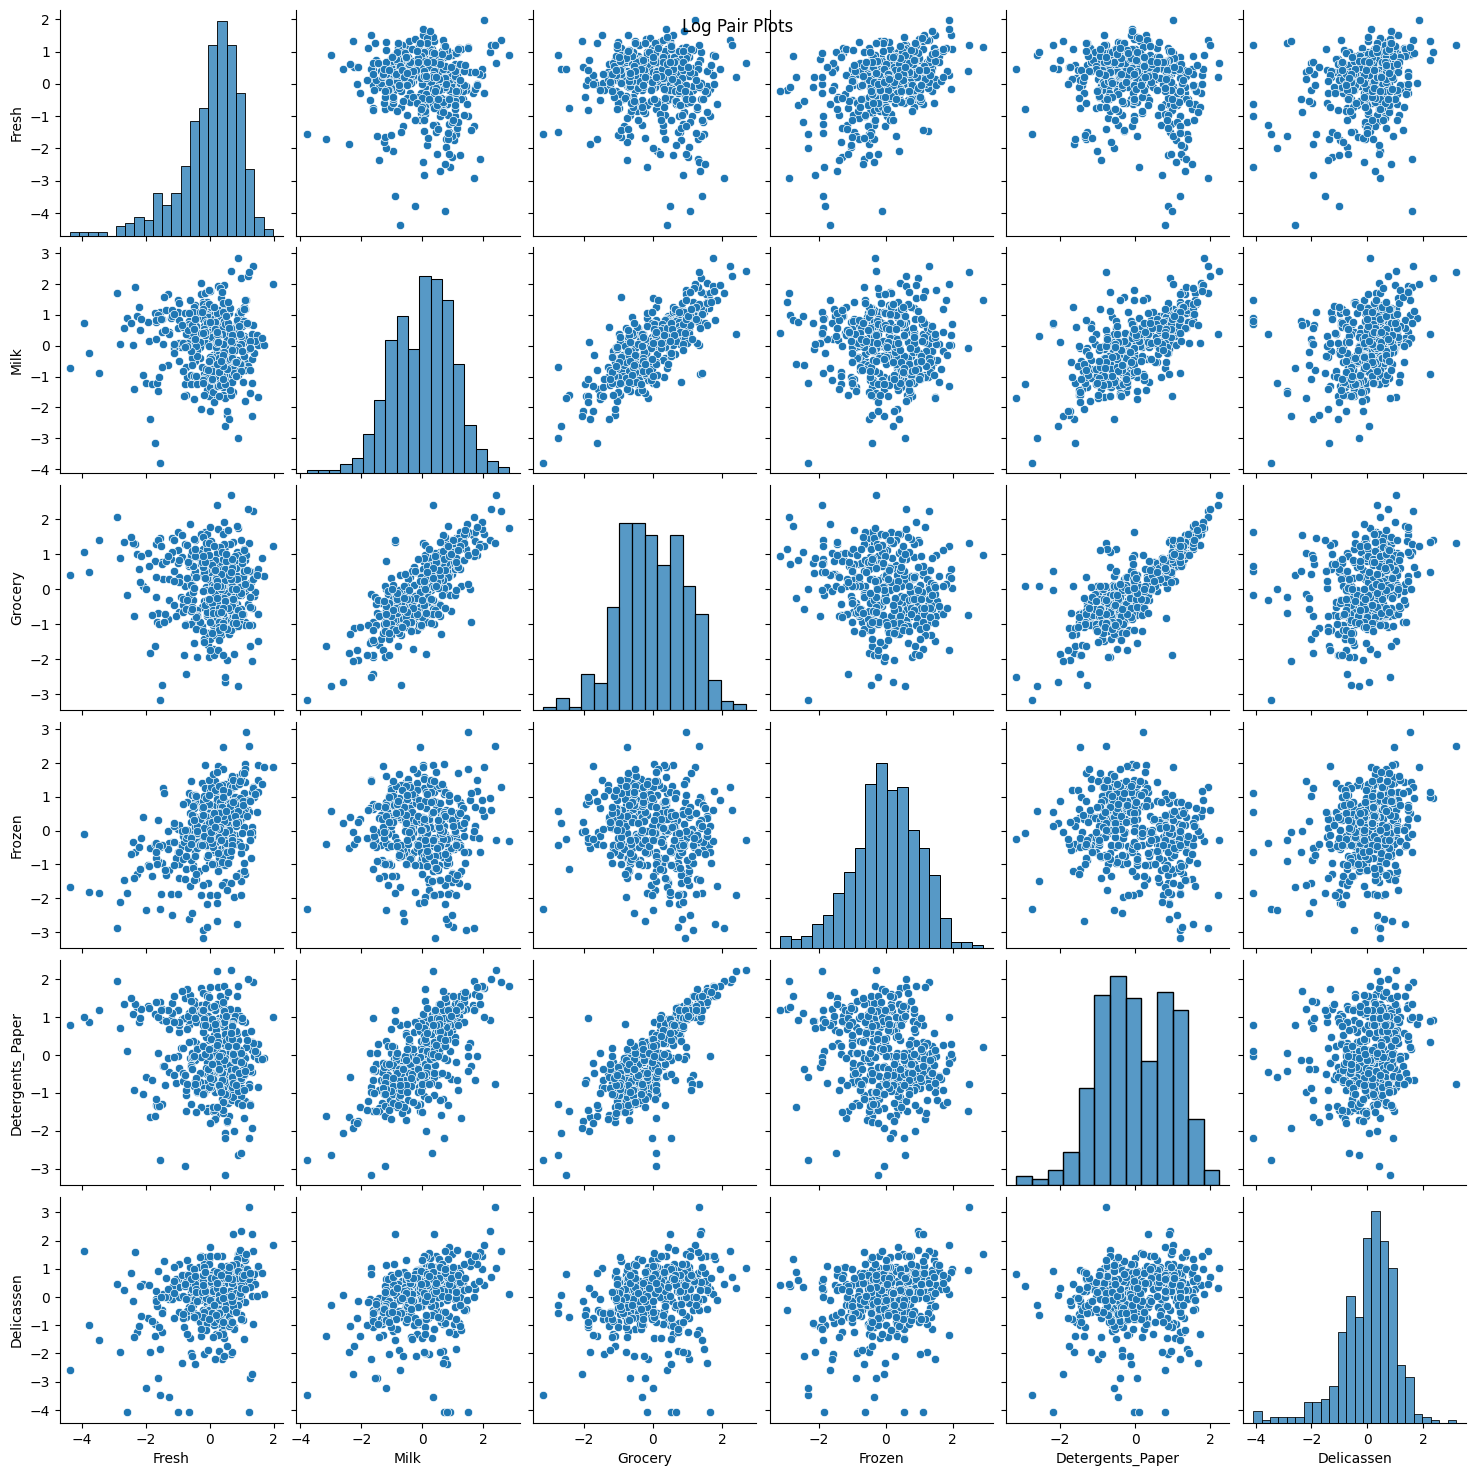

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

z.hist(figsize=(10,8))
plt.suptitle("Z-score Histograms")
plt.show()

log.hist(figsize=(10,8))
plt.suptitle("Log Histograms")
plt.show()

sns.pairplot(z)
plt.suptitle("Z-score Pair Plots")
plt.show()

sns.pairplot(log)
plt.suptitle("Log Pair Plots")
plt.show()


#### Statistical Tests

One of the clustering algorithms, Gaussian Mixture Models, works best if the features are normally distributed.

One method to determine if data is normally distributed is a [Shapiro-Wilk Test](https://en.wikipedia.org/wiki/Shapiro%E2%80%93Wilk_test). Perform a Shapiro-Wilk test on each column of the both the Z-score scaled data and the log-transformed data and print out if the test says that the column is normally distributed at a significance level of 0.05.

---
**Hints**
- [`scipy.stats.shapiro()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html)


In [ ]:
from scipy.stats import shapiro

print("Z-score Data:")
for col in z.columns:
    stat, p = shapiro(z[col].sample(5000) if len(z) > 5000 else z[col])
    print(col, "Normal" if p > 0.05 else "Not normal")

print("\nLog Data:")
for col in log.columns:
    stat, p = shapiro(log[col].sample(5000) if len(log) > 5000 else log[col])
    print(col, "Normal" if p > 0.05 else "Not normal")


Z-score Data:
Fresh Not normal
Milk Not normal
Grocery Not normal
Frozen Not normal
Detergents_Paper Not normal
Delicassen Not normal

Log Data:
Fresh Not normal
Milk Normal
Grocery Not normal
Frozen Not normal
Detergents_Paper Not normal
Delicassen Not normal


## Models

Compare Gaussian Mixture Models and Agglomerative Clustering algorithms on both preprocessed data sets using the Silhouette score, Calinski-Harabasz score, and Davies-Bouldin score. Only use the following 3 features: `['Frozen', 'Detergents_Paper', 'Delicassen']`. Results will be visualized on a 3-D scatter plot.

_Note: do not do a train/test split. Evaluate the clustering results on the entire data set._


In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [ ]:
import plotly.express as px

cluster_cols = ['Frozen', 'Detergents_Paper', 'Delicassen']

def plot_3d_clustering(data, labels, columns=cluster_cols):
    """
    Function to create a 3D plot to visualize clustering results using Plotly.

    Parameters:
    - data: The DataFrame containing the data.
    - labels: The array of cluster labels.
    - columns: A list of three column names to plot.
    """
    col1, col2, col3 = columns

    # Create a DataFrame with the selected columns and the cluster labels
    plot_data = data[[col1, col2, col3]].copy()
    plot_data['Cluster'] = labels.astype(str)

    # Create a 3D scatter plot using Plotly
    fig = px.scatter_3d(plot_data, x=col1, y=col2, z=col3, color='Cluster', opacity=0.7,
                        title='3D Clustering Visualization',
                        labels={col1: col1, col2: col2, col3: col3, 'Cluster': 'Cluster'})

    fig.show()

#### Gaussian Mixture Model

Do a grid search across the the following number of clusters (`n_components`) for the `GaussianMixture` algorithm. Evaluate each clustering result using the three metrics mentioned above. Do this for both the z-score scaled and log transformed data sets. Pick the hyperparameters and data set that give best result and plot it using the `plot_3d_clustering()` function defined above.


_Hyperparameters_
```
{
    'n_components': [2, 3, 4, 5, 6],
}
```

---
**Hints**

_Modeling_
- [`sklearn.mixture.GaussianMixture`](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html)

_Metrics_

- [`sklearn.metrics.silhouette_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)
- [`sklearn.metrics.calinski_harabasz_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.calinski_harabasz_score.html)
- [`sklearn.metrics.davies_bouldin_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.davies_bouldin_score.html)




In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

X_z = z[['Frozen', 'Detergents_Paper', 'Delicassen']]
X_log = log[['Frozen', 'Detergents_Paper', 'Delicassen']]

for data_name, X in [('Z-score', X_z), ('Log', X_log)]:
    print(f"\n{data_name} Data")
    for n in [2,3,4,5,6]:
        gmm = GaussianMixture(n_components=n, random_state=42)
        labels = gmm.fit_predict(X)

        sil = silhouette_score(X, labels)
        ch = calinski_harabasz_score(X, labels)
        db = davies_bouldin_score(X, labels)

        print(f"Clusters={n}: Silhouette={sil:.3f}, CH={ch:.1f}, DB={db:.3f}")

best_gmm = GaussianMixture(n_components=3, random_state=42)
best_labels = best_gmm.fit_predict(X_log)
plot_3d_clustering(X_log, best_labels)



Z-score Data
Clusters=2: Silhouette=0.301, CH=148.5, DB=1.357
Clusters=3: Silhouette=0.279, CH=161.3, DB=1.056
Clusters=4: Silhouette=0.260, CH=150.5, DB=1.206
Clusters=5: Silhouette=0.226, CH=129.2, DB=1.379
Clusters=6: Silhouette=0.300, CH=168.9, DB=0.936

Log Data
Clusters=2: Silhouette=0.286, CH=83.6, DB=1.953
Clusters=3: Silhouette=0.226, CH=129.4, DB=1.363
Clusters=4: Silhouette=0.240, CH=103.2, DB=1.703
Clusters=5: Silhouette=0.269, CH=156.6, DB=1.141
Clusters=6: Silhouette=0.253, CH=122.9, DB=1.271


#### Agglomerative Clustering

Do a grid search across the the following hyperparameters for the `AgglomerativeClustering` algorithm. Evaluate each clustering result using the three metrics mentioned above. Do this for both the z-score scaled and log transformed data sets. Pick the hyperparameters and data set that give best result and plot it using the `plot_3d_clustering()` function defined above.


_Hyperparameters_
```
{
    'n_clusters': [2, 3, 4, 5, 6],
    'linkage': ['complete', 'single']
}
```

---
**Hints**

_Modeling_
- [`sklearn.cluster.AgglomerativeClustering`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

_Metrics_

- [`sklearn.metrics.silhouette_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)
- [`sklearn.metrics.calinski_harabasz_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.calinski_harabasz_score.html)
- [`sklearn.metrics.davies_bouldin_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.davies_bouldin_score.html)




In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

X_z = z[['Frozen', 'Detergents_Paper', 'Delicassen']]
X_log = log[['Frozen', 'Detergents_Paper', 'Delicassen']]

for data_name, X in [('Z-score', X_z), ('Log', X_log)]:
    print(f"\n{data_name} Data")
    for n in [2,3,4,5,6]:
        for linkage in ['complete','single']:
            agg = AgglomerativeClustering(n_clusters=n, linkage=linkage)
            labels = agg.fit_predict(X)

            sil = silhouette_score(X, labels)
            ch = calinski_harabasz_score(X, labels)
            db = davies_bouldin_score(X, labels)

            print(f"Clusters={n}, Linkage={linkage}: Sil={sil:.3f}, CH={ch:.1f}, DB={db:.3f}")

best_agg = AgglomerativeClustering(n_clusters=3, linkage='complete')
best_labels = best_agg.fit_predict(X_log)
plot_3d_clustering(X_log, best_labels)



Z-score Data
Clusters=2, Linkage=complete: Sil=0.582, CH=119.3, DB=0.593
Clusters=2, Linkage=single: Sil=0.726, CH=35.5, DB=0.258
Clusters=3, Linkage=complete: Sil=0.589, CH=89.3, DB=0.469
Clusters=3, Linkage=single: Sil=0.682, CH=27.2, DB=0.237
Clusters=4, Linkage=complete: Sil=0.546, CH=94.9, DB=0.446
Clusters=4, Linkage=single: Sil=0.642, CH=27.2, DB=0.281
Clusters=5, Linkage=complete: Sil=0.385, CH=139.0, DB=0.651
Clusters=5, Linkage=single: Sil=0.628, CH=24.0, DB=0.335
Clusters=6, Linkage=complete: Sil=0.387, CH=134.6, DB=0.658
Clusters=6, Linkage=single: Sil=0.625, CH=19.2, DB=0.235

Log Data
Clusters=2, Linkage=complete: Sil=0.343, CH=95.3, DB=1.241
Clusters=2, Linkage=single: Sil=0.557, CH=8.6, DB=0.309
Clusters=3, Linkage=complete: Sil=0.254, CH=138.5, DB=1.311
Clusters=3, Linkage=single: Sil=0.420, CH=7.3, DB=0.353
Clusters=4, Linkage=complete: Sil=0.214, CH=125.3, DB=1.205
Clusters=4, Linkage=single: Sil=0.389, CH=7.1, DB=0.353
Clusters=5, Linkage=complete: Sil=0.208, CH=10

## Conclusions

**In the data visualization of each of the 2 preprocessed data sets, what are the main differences you notice between the scaling methods? Also, What variables appear to be correlated with each other based on these graphs?**


_The Z histograms are spread mostly from -1 to 2, skewed left. Whereas log histograms ranges form -3 to 2 the shape looks like normal bell shaped. Milk, Grocery, and Detergents_Paper appears to be positively correlated as they are forming upward trending lines._

**Do the results of the Shapiro-Wilk tests generally match with what you see in the graphs of each variables distribution - do they look normally distributed and does the Shapiro-Wilk test say it they are normally distributed or not? Also, what other methods or tests could be done to test for normality?**


_Only Milk has paased the normality test and did not capture all expected variables. Other variables appear roughly normal(bell-shaped) visually but fail the test. Q-Q plots are another way to check for normality._

**Which algorithm, hyperparameters, and data set gave the best clustering result? Give reasons for why it is "best" _(better metrics, more visually separated clusters, etc.)_**

_The best result was Agglomerative Clustering on Z-score data with 2 clusters and single linkage. It had a high Silhouette score (0.726) and low Davies-Bouldin score (0.258), showing clear clusters in the 3D plot._

**If you continued to try improving the clustering results, what would be your next steps?**


_I would try to use more feature and test different scaling methods also check and see how K-means would perform on this. I would also love to see how it would be if I tune hyperparameters more precisely and remove outliners._